##Time and Date

Content modified from:

McKinney, W. (2018). Python for data analysis. Ch. 11. O'Reilly Media.

Powerful Python data analysis toolkit, Release 1.3.4. See https://pandas.pydata.org/pandas-docs/version/1.3.4/pandas.pdf

Pandas datetime functionality: https://pandas.pydata.org/docs/user_guide/timeseries.html

In [151]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [152]:
%run '/content/drive/MyDrive/Google_connection.py'

Changed directoGit_HUBry to: /content/MSSP-607/WeeklyModules/Week08/MSSP-607


<Figure size 1000x600 with 0 Axes>

In [153]:
%pushd "/content/MSSP-607/WeeklyModules/Week08"

/content/MSSP-607/WeeklyModules/Week08


['/content/MSSP-607/WeeklyModules/Week08/MSSP-607',
 '/content/MSSP-607/WeeklyModules/Week08/MSSP-607',
 '/content/MSSP-607']

In [154]:
import numpy as np
import pandas as pd
np.random.seed(12345)
import matplotlib.pyplot as plt
plt.rc('figure', figsize=(10, 6))
PREVIOUS_MAX_ROWS = pd.options.display.max_rows
pd.options.display.max_rows = 20
np.set_printoptions(precision=4, suppress=True)

## Date and Time Data Types and Tools

From Pandas documentation: "pandas contains extensive capabilities and features for working with time series data for all domains. Using the NumPy datetime64 and timedelta64 dtypes, pandas has consolidated a large number of features from other Python libraries like scikits.timeseries as well as created a tremendous amount of new functionality for manipulating time series data."

Pandas expands on the standard Python library's "datetime" module.

See also modules for:

calendar: https://docs.python.org/3/library/calendar.html#module-calendar

time: https://docs.python.org/3/library/time.html#module-time

zone: https://docs.python.org/3/library/zoneinfo.html#module-zoneinfo

and package documentation:

dateutil: https://dateutil.readthedocs.io/en/stable/

The dateutil package is primarily used for parsing dates, managing time zones, and working with relativedeltas (relative date operations like adding a month to a date).

In [155]:
#Import the datetime module
#Date and time objects may be categorized as “aware” or “naive” depending on whether
#or not they include time zone information.
#From datetime module documentation:

#Objects of the date type are always naive.

#An object of type time or datetime may be aware or naive.

#A datetime object d is aware if both of the following hold:

#d.tzinfo is not None

#d.tzinfo.utcoffset(d) does not return None

#Otherwise, d is naive.

#A time object t is aware if both of the following hold:

#t.tzinfo is not None

#t.tzinfo.utcoffset(None) does not return None.

#Otherwise, t is naive.

#the distinction between aware and naive doesn’t apply to timedelta objects.

from datetime import datetime
now = datetime.now()
now
now.year, now.month, now.day

(2025, 10, 27)

In [156]:
#Determining datetime delta

delta = datetime(2011, 1, 7) - datetime(2008, 6, 24, 8, 15) #Returns datetime.timedelta(days=926, seconds=56700)
delta
delta.days #926
delta.seconds #seconds
print("The delta between 2011-01-7 and 2008-06-24 is",delta.days,"days and",delta.seconds,"seconds")

The delta between 2011-01-7 and 2008-06-24 is 926 days and 56700 seconds


In [157]:
#Difference between two datetime values.
#timedelta(days=0, seconds=0, microseconds=0, milliseconds=0, minutes=0, hours=0, weeks=0)
#All arguments are optional and default to 0. Arguments may be integers or floats, and may be positive or negative.
from datetime import timedelta
start = datetime(2011, 1, 7)
print("Start date plus 12 days is", start + timedelta(12), " and the start minus 24 days is ", start - 2 * timedelta(12))


Start date plus 12 days is 2011-01-19 00:00:00  and the start minus 24 days is  2010-12-14 00:00:00


### Converting Between String and Datetime

In [158]:
#Return a string representing the date, controlled by an explicit format string.
#Format codes referring to hours, minutes or seconds will see 0 values.
#See https://docs.python.org/3/library/datetime.html#datetime.date.strftime

#And

#strftime() and strptime() Format Codes: https://docs.python.org/3/library/datetime.html#format-codes

stamp = datetime(2011, 1, 3)  #creates a daetime object
str(stamp)  #explicity convert the datetime object to a string.
stamp.strftime('%Y-%m-%d')  #calling the string to datetime function the format codes are '%Y-%m-%d'

'2011-01-03'

In [159]:
#Return a datetime corresponding to date_string, parsed according to format.
value = '2011-01-03'
datetime.strptime(value, '%Y-%m-%d')
datestrs = ['7/6/2011', '8/6/2011']
[datetime.strptime(x, '%m/%d/%Y') for x in datestrs]

[datetime.datetime(2011, 7, 6, 0, 0), datetime.datetime(2011, 8, 6, 0, 0)]

In [160]:
#The parse function is very powerful for converting strings into datetime objects,
#as it can handle many different date formats.

from dateutil.parser import parse
parse('2011-01-03')

datetime.datetime(2011, 1, 3, 0, 0)

In [161]:
parse('Jan 31, 1997 10:45 PM')

datetime.datetime(1997, 1, 31, 22, 45)

In [162]:
#Whether to interpret the first value in an ambiguous 3-integer date
#(e.g. 01/05/09) as the day (True) or month (False). If
#yearfirst is set to True, this distinguishes between YDM and
#YMD. If set to None, this value is retrieved from the current
#parserinfo object (which itself defaults to False).
parse('6/12/2011', dayfirst=True)

datetime.datetime(2011, 12, 6, 0, 0)

In [163]:
#Using Pandas to_datetime functions to convert  scalar, array-like, Series
#or DataFrame/dict-like to a pandas datetime object.
datestrs = ['2011-07-06 12:00:00', '2011-08-06 00:00:00']
pd.to_datetime(datestrs)

DatetimeIndex(['2011-07-06 12:00:00', '2011-08-06 00:00:00'], dtype='datetime64[ns]', freq=None)

In [164]:
#Converts the datestrs lists plus a None value to datetime and test for null values
idx = pd.to_datetime(datestrs + [None])
idx #Returns a NaT in the second index
idx[2]
print(idx[2]," and ", pd.isnull(idx))

NaT  and  [False False  True]


## Time Series Basics

In [165]:
#Create a series with a datetime index
from datetime import datetime
dates = [datetime(2011, 1, 2), datetime(2011, 1, 5),
         datetime(2011, 1, 7), datetime(2011, 1, 8),
         datetime(2011, 1, 10), datetime(2011, 1, 12)]
ts = pd.Series(np.random.randn(6), index=dates)
ts

,0
2011-01-02,-0.20
2011-01-05,0.48
2011-01-07,-0.52
2011-01-08,-0.56
2011-01-10,1.97
2011-01-12,1.39


In [166]:
#Output the index of the Series.
ts.index

DatetimeIndex(['2011-01-02', '2011-01-05', '2011-01-07', '2011-01-08',
               '2011-01-10', '2011-01-12'],
              dtype='datetime64[ns]', freq=None)

In [167]:
#In slicing notation ts[start:stop:step], the third element (step) specifies the step size for selecting elements.
ts + ts[::2]

,0
2011-01-02,-0.41
2011-01-05,NaN
2011-01-07,-1.04
2011-01-08,NaN
2011-01-10,3.93
2011-01-12,NaN


In [168]:
#The dtype property of an Index tells you what type of data is stored in the index (e.g., integers, strings, dates, etc.).
#< byte order
#M datetime
#8 stored as eight bytes
#ns datetime types stored nanoseconds precision
ts.index.dtype

dtype('<M8[ns]')

In [169]:
#Indexing the time series
stamp = ts.index[0]
stamp

Timestamp('2011-01-02 00:00:00')

### Indexing, Selection, Subsetting

In [170]:
#Output time series just to reveiw
ts

,0
2011-01-02,-0.20
2011-01-05,0.48
2011-01-07,-0.52
2011-01-08,-0.56
2011-01-10,1.97
2011-01-12,1.39


In [171]:
#Index the time series
stamp = ts.index[2]

#Return the series value at the index
ts[stamp]

np.float64(-0.5194387150567381)

In [172]:
#The date format used in your code must match the index of teh datetime indesight not match the format of the dates in the index of the ts Series.
#ts['1102011']) produces an error
#ts['20110110'] produces and error
ts['2011-01-02']

np.float64(-0.20470765948471295)

In [173]:
#Create alonger time series
longer_ts = pd.Series(np.random.randn(1000),
                      index=pd.date_range('1/1/2000', periods=1000))
longer_ts
longer_ts['2001'] #Output 2001 year

,0
2001-01-01,1.60
2001-01-02,0.47
2001-01-03,0.15
2001-01-04,-0.54
2001-01-05,-0.48
...,...
2001-12-27,0.06
2001-12-28,-0.43
2001-12-29,0.09
2001-12-30,-1.40


In [174]:
#Return the month of May using the Year-month of the index
longer_ts['2001-05']

,0
2001-05-01,-0.62
2001-05-02,0.94
2001-05-03,0.75
2001-05-04,-0.06
2001-05-05,2.30
...,...
2001-05-27,0.24
2001-05-28,0.11
2001-05-29,-1.25
2001-05-30,-2.95


In [175]:
#Slice the series from start to end
ts[datetime(2001, 1, 7):]

,0
2011-01-02,-0.20
2011-01-05,0.48
2011-01-07,-0.52
2011-01-08,-0.56
2011-01-10,1.97
2011-01-12,1.39


In [176]:
#Slice the series between dates
ts
ts['1/6/2011':'1/11/2011']

,0
2011-01-07,-0.52
2011-01-08,-0.56
2011-01-10,1.97


In [177]:
#Delete records after a certain date
ts.truncate(after='1/9/2011')

,0
2011-01-02,-0.20
2011-01-05,0.48
2011-01-07,-0.52
2011-01-08,-0.56


In [178]:
#Return a fixed frequency DatetimeIndex.

#Returns the range of equally spaced time points (where the difference between
#any two adjacent points is specified by the given frequency) such that they
#all satisfy start <[=] x <[=] end, where the first one and the last one are, resp.,
#the first and last time points in that range that fall on the boundary of
#freq (if given as a frequency string) or that are valid for freq (if given as a
#pandas.tseries.offsets.DateOffset).

#See https://pandas.pydata.org/docs/user_guide/timeseries.html#timeseries-offset-aliases
#for a list of frequency aliases.

#For some frequencies you can specify an anchoring suffix.  For example, weekly anchored
#Wednesdays ('W-WED')


dates = pd.date_range('1/1/2000', periods=100, freq='W-WED')
long_df = pd.DataFrame(np.random.randn(100, 4),
                       index=dates,
                       columns=['Colorado', 'Texas',
                                'New York', 'Ohio'])
long_df.loc['5-2001']

,Colorado,Texas,New York,Ohio
2001-05-02,-0.01,0.49,-0.28,-0.71
2001-05-09,-0.56,2.74,0.93,1.51
2001-05-16,0.54,1.27,0.67,-0.97
2001-05-23,1.68,-0.82,0.05,1.95
2001-05-30,3.26,0.96,1.20,-1.85


### Time Series with Duplicate Indices

In [179]:
#In some applications, there may be duplicate observations on a given timestatmp.
dates = pd.DatetimeIndex(['1/1/2000', '1/2/2000', '1/2/2000',
                          '1/2/2000', '1/3/2000'])
dup_ts = pd.Series(np.arange(5), index=dates)
dup_ts

,0
2000-01-01,0
2000-01-02,1
2000-01-02,2
2000-01-02,3
2000-01-03,4


In [180]:
#We can test to see if an index is unique.
dup_ts.index.is_unique

False

In [181]:
dup_ts['1/3/2000']  # not duplicated

np.int64(4)

In [182]:
dup_ts['1/2/2000']  # duplicated

,0
2000-01-02,1
2000-01-02,2
2000-01-02,3


In [183]:
#To aggregate on data having nonunique timestamps, you can pass the level parameter to specify
#the level to index. If the axis is a MultiIndex (hierarchical), group by a particular
#level or levels.

#To group on the just on the duplicated timestamp, specify level=0 - first level only.

grouped = dup_ts.groupby(level=0)
grouped.mean()

,0
2000-01-01,0.00
2000-01-02,2.00
2000-01-03,4.00


In [184]:
grouped.count()

,0
2000-01-01,1
2000-01-02,3
2000-01-03,1


## Date Ranges, Frequencies, and Shifting

In [185]:
#To convert or adjust the frequency of time-indexed data use the resample method. It’s somewhat similar to groupby,
#but it's designed to work with time-based data.

#See documentation: https://pandas.pydata.org/docs/reference/api/pandas.Series.resample.html#pandas.Series.resample
#Convenience method for frequency conversion and resampling of time series. The object must have a datetime-like index
 #(DatetimeIndex, PeriodIndex, or TimedeltaIndex), or the caller must pass the label of a datetime-like series/index
 #to the on/level keyword parameter.

ts
resampler = ts.resample('D')


### Generating Date Ranges

In [186]:
#Return a range of equally spaced timestamps:  a daily (freq='D') date range
index = pd.date_range('2012-04-01', '2012-06-01')
index

DatetimeIndex(['2012-04-01', '2012-04-02', '2012-04-03', '2012-04-04',
               '2012-04-05', '2012-04-06', '2012-04-07', '2012-04-08',
               '2012-04-09', '2012-04-10', '2012-04-11', '2012-04-12',
               '2012-04-13', '2012-04-14', '2012-04-15', '2012-04-16',
               '2012-04-17', '2012-04-18', '2012-04-19', '2012-04-20',
               '2012-04-21', '2012-04-22', '2012-04-23', '2012-04-24',
               '2012-04-25', '2012-04-26', '2012-04-27', '2012-04-28',
               '2012-04-29', '2012-04-30', '2012-05-01', '2012-05-02',
               '2012-05-03', '2012-05-04', '2012-05-05', '2012-05-06',
               '2012-05-07', '2012-05-08', '2012-05-09', '2012-05-10',
               '2012-05-11', '2012-05-12', '2012-05-13', '2012-05-14',
               '2012-05-15', '2012-05-16', '2012-05-17', '2012-05-18',
               '2012-05-19', '2012-05-20', '2012-05-21', '2012-05-22',
               '2012-05-23', '2012-05-24', '2012-05-25', '2012-05-26',
      

In [187]:
#Number of periods to generate.
pd.date_range(start='2012-04-01', periods=20)
pd.date_range(end='2012-06-01', periods=20)

DatetimeIndex(['2012-05-13', '2012-05-14', '2012-05-15', '2012-05-16',
               '2012-05-17', '2012-05-18', '2012-05-19', '2012-05-20',
               '2012-05-21', '2012-05-22', '2012-05-23', '2012-05-24',
               '2012-05-25', '2012-05-26', '2012-05-27', '2012-05-28',
               '2012-05-29', '2012-05-30', '2012-05-31', '2012-06-01'],
              dtype='datetime64[ns]', freq='D')

In [188]:
#BME: business month end frequency
pd.date_range('2000-01-01', '2000-12-01', freq='BME')

DatetimeIndex(['2000-01-31', '2000-02-29', '2000-03-31', '2000-04-28',
               '2000-05-31', '2000-06-30', '2000-07-31', '2000-08-31',
               '2000-09-29', '2000-10-31', '2000-11-30'],
              dtype='datetime64[ns]', freq='BME')

In [189]:
pd.date_range('2012-05-02 12:56:31', periods=5)

DatetimeIndex(['2012-05-02 12:56:31', '2012-05-03 12:56:31',
               '2012-05-04 12:56:31', '2012-05-05 12:56:31',
               '2012-05-06 12:56:31'],
              dtype='datetime64[ns]', freq='D')

In [190]:
#Normalize start/end dates to midnight before generating date range.
#name : str, default None
pd.date_range('2012-05-02 12:56:31', periods=5, normalize=True)

DatetimeIndex(['2012-05-02', '2012-05-03', '2012-05-04', '2012-05-05',
               '2012-05-06'],
              dtype='datetime64[ns]', freq='D')

### Frequencies and Date Offsets

In [191]:
#See: https://pandas.pydata.org/docs/reference/offset_frequency.html
#Date offsets: Standard kind of date increment used for a date range.
#Hour: offset in 'n' hours
#Minute: offset in 'n' minutes

from pandas.tseries.offsets import Hour, Minute
hour = Hour() #create an instance of an hour class
hour

<Hour>

In [192]:
#Define offset variable
four_hours = Hour(4)
four_hours

<4 * Hours>

In [193]:
#Create a date range with 4 hour offsets
pd.date_range('2000-01-01', '2000-01-03 23:59', freq='4h')

DatetimeIndex(['2000-01-01 00:00:00', '2000-01-01 04:00:00',
               '2000-01-01 08:00:00', '2000-01-01 12:00:00',
               '2000-01-01 16:00:00', '2000-01-01 20:00:00',
               '2000-01-02 00:00:00', '2000-01-02 04:00:00',
               '2000-01-02 08:00:00', '2000-01-02 12:00:00',
               '2000-01-02 16:00:00', '2000-01-02 20:00:00',
               '2000-01-03 00:00:00', '2000-01-03 04:00:00',
               '2000-01-03 08:00:00', '2000-01-03 12:00:00',
               '2000-01-03 16:00:00', '2000-01-03 20:00:00'],
              dtype='datetime64[ns]', freq='4h')

In [194]:
#Using Hour and Minute classes to caclulate time
Hour(2) + Minute(30)

<150 * Minutes>

In [195]:
#Create 90 minute intervals.
pd.date_range('2000-01-01', periods=10, freq='1h30min')

DatetimeIndex(['2000-01-01 00:00:00', '2000-01-01 01:30:00',
               '2000-01-01 03:00:00', '2000-01-01 04:30:00',
               '2000-01-01 06:00:00', '2000-01-01 07:30:00',
               '2000-01-01 09:00:00', '2000-01-01 10:30:00',
               '2000-01-01 12:00:00', '2000-01-01 13:30:00'],
              dtype='datetime64[ns]', freq='90min')

#### Week of month dates

In [196]:
#Week of month ending on the 3rd Friday
rng = pd.date_range('2012-01-01', '2012-09-01', freq='WOM-3FRI')
list(rng)

[Timestamp('2012-01-20 00:00:00'),
 Timestamp('2012-02-17 00:00:00'),
 Timestamp('2012-03-16 00:00:00'),
 Timestamp('2012-04-20 00:00:00'),
 Timestamp('2012-05-18 00:00:00'),
 Timestamp('2012-06-15 00:00:00'),
 Timestamp('2012-07-20 00:00:00'),
 Timestamp('2012-08-17 00:00:00')]

### Shifting (Leading and Lagging) Data

In [197]:
#The shift() method in pandas shifts the data in the Series by a specified number of periods.
ts = pd.Series(np.random.randn(4),
               index=pd.date_range('1/1/2000', periods=4, freq='ME'))
ts
ts.shift(2)


,0
2000-01-31,NaN
2000-02-29,NaN
2000-03-31,-0.07
2000-04-30,0.84


In [198]:
ts.shift(-2)

,0
2000-01-31,-0.12
2000-02-29,-0.52
2000-03-31,NaN
2000-04-30,NaN


ts / ts.shift(1) - 1

In [199]:
ts.shift(2, freq='ME')

,0
2000-03-31,-0.07
2000-04-30,0.84
2000-05-31,-0.12
2000-06-30,-0.52


In [200]:
ts.shift(3, freq='D')
ts.shift(1, freq='90min')

,0
2000-01-31 01:30:00,-0.07
2000-02-29 01:30:00,0.84
2000-03-31 01:30:00,-0.12
2000-04-30 01:30:00,-0.52


#### Shifting dates with offsets

In [201]:
from pandas.tseries.offsets import Day, MonthEnd
now = datetime(2011, 11, 17)
now + 3 * Day()

Timestamp('2011-11-20 00:00:00')

In [202]:
now + MonthEnd()
now + MonthEnd(2)

Timestamp('2011-12-31 00:00:00')

In [203]:
offset = MonthEnd()
offset.rollforward(now)
offset.rollback(now)

Timestamp('2011-10-31 00:00:00')

In [204]:
ts = pd.Series(np.random.randn(20),
               index=pd.date_range('1/15/2000', periods=20, freq='4d'))
ts
ts.groupby(offset.rollforward).mean()

,0
2000-01-31,-0.01
2000-02-29,0.02
2000-03-31,0.15


In [205]:
ts.resample('ME').mean()

,0
2000-01-31,-0.01
2000-02-29,0.02
2000-03-31,0.15


## Time Zone Handling

In [206]:
import pytz
pytz.common_timezones[-5:]

['US/Eastern', 'US/Hawaii', 'US/Mountain', 'US/Pacific', 'UTC']

In [207]:
tz = pytz.timezone('America/New_York')
tz

<DstTzInfo 'America/New_York' LMT-1 day, 19:04:00 STD>

### Time Zone Localization and Conversion

In [208]:
rng = pd.date_range('3/9/2012 9:30', periods=6, freq='D')
ts = pd.Series(np.random.randn(len(rng)), index=rng)
ts

,0
2012-03-09 09:30:00,-0.20
2012-03-10 09:30:00,0.05
2012-03-11 09:30:00,0.64
2012-03-12 09:30:00,0.60
2012-03-13 09:30:00,-0.80
2012-03-14 09:30:00,0.47


In [209]:
print(ts.index.tz)

None


In [210]:
pd.date_range('3/9/2012 9:30', periods=10, freq='D', tz='UTC')

DatetimeIndex(['2012-03-09 09:30:00+00:00', '2012-03-10 09:30:00+00:00',
               '2012-03-11 09:30:00+00:00', '2012-03-12 09:30:00+00:00',
               '2012-03-13 09:30:00+00:00', '2012-03-14 09:30:00+00:00',
               '2012-03-15 09:30:00+00:00', '2012-03-16 09:30:00+00:00',
               '2012-03-17 09:30:00+00:00', '2012-03-18 09:30:00+00:00'],
              dtype='datetime64[ns, UTC]', freq='D')

In [211]:
ts
ts_utc = ts.tz_localize('UTC')
ts_utc
ts_utc.index

DatetimeIndex(['2012-03-09 09:30:00+00:00', '2012-03-10 09:30:00+00:00',
               '2012-03-11 09:30:00+00:00', '2012-03-12 09:30:00+00:00',
               '2012-03-13 09:30:00+00:00', '2012-03-14 09:30:00+00:00'],
              dtype='datetime64[ns, UTC]', freq='D')

In [212]:
ts_utc.tz_convert('America/New_York')

,0
2012-03-09 04:30:00-05:00,-0.20
2012-03-10 04:30:00-05:00,0.05
2012-03-11 05:30:00-04:00,0.64
2012-03-12 05:30:00-04:00,0.60
2012-03-13 05:30:00-04:00,-0.80
2012-03-14 05:30:00-04:00,0.47


In [213]:
ts_eastern = ts.tz_localize('America/New_York')
ts_eastern.tz_convert('UTC')
ts_eastern.tz_convert('Europe/Berlin')

,0
2012-03-09 15:30:00+01:00,-0.20
2012-03-10 15:30:00+01:00,0.05
2012-03-11 14:30:00+01:00,0.64
2012-03-12 14:30:00+01:00,0.60
2012-03-13 14:30:00+01:00,-0.80
2012-03-14 14:30:00+01:00,0.47


In [214]:
ts.index.tz_localize('Asia/Shanghai')

DatetimeIndex(['2012-03-09 09:30:00+08:00', '2012-03-10 09:30:00+08:00',
               '2012-03-11 09:30:00+08:00', '2012-03-12 09:30:00+08:00',
               '2012-03-13 09:30:00+08:00', '2012-03-14 09:30:00+08:00'],
              dtype='datetime64[ns, Asia/Shanghai]', freq=None)

### Operations with Time Zone−Aware Timestamp Objects

In [215]:
stamp = pd.Timestamp('2011-03-12 04:00')
stamp_utc = stamp.tz_localize('utc')
stamp_utc.tz_convert('America/New_York')

Timestamp('2011-03-11 23:00:00-0500', tz='America/New_York')

In [216]:
stamp_moscow = pd.Timestamp('2011-03-12 04:00', tz='Europe/Moscow')
stamp_moscow

Timestamp('2011-03-12 04:00:00+0300', tz='Europe/Moscow')

In [217]:
stamp_utc.value
stamp_utc.tz_convert('America/New_York').value

1299902400000000000

In [218]:
from pandas.tseries.offsets import Hour
stamp = pd.Timestamp('2012-03-12 01:30', tz='US/Eastern')
stamp
stamp + Hour()

Timestamp('2012-03-12 02:30:00-0400', tz='US/Eastern')

In [219]:
stamp = pd.Timestamp('2012-11-04 00:30', tz='US/Eastern')
stamp
stamp + 2 * Hour()

Timestamp('2012-11-04 01:30:00-0500', tz='US/Eastern')

### Operations Between Different Time Zones

In [220]:
rng = pd.date_range('3/7/2012 9:30', periods=10, freq='B')
ts = pd.Series(np.random.randn(len(rng)), index=rng)
ts
ts1 = ts[:7].tz_localize('Europe/London')
ts2 = ts1[2:].tz_convert('Europe/Moscow')
result = ts1 + ts2
result.index

DatetimeIndex(['2012-03-07 09:30:00+00:00', '2012-03-08 09:30:00+00:00',
               '2012-03-09 09:30:00+00:00', '2012-03-12 09:30:00+00:00',
               '2012-03-13 09:30:00+00:00', '2012-03-14 09:30:00+00:00',
               '2012-03-15 09:30:00+00:00'],
              dtype='datetime64[ns, UTC]', freq=None)

## Periods and Period Arithmetic

In [221]:
p = pd.Period(2007, freq='Y-DEC')
p

Period('2007', 'Y-DEC')

In [222]:
p + 5
p - 2

Period('2005', 'Y-DEC')

In [223]:
pd.Period('2014', freq='Y-DEC') - p

<7 * YearEnds: month=12>

In [224]:
rng = pd.period_range('2000-01-01', '2000-06-30', freq='M')
rng

PeriodIndex(['2000-01', '2000-02', '2000-03', '2000-04', '2000-05', '2000-06'], dtype='period[M]')

In [225]:
pd.Series(np.random.randn(6), index=rng)

,0
2000-01,-0.51
2000-02,-0.56
2000-03,-0.78
2000-04,-1.80
2000-05,-0.17
2000-06,0.68


In [226]:
values = ['2001Q3', '2002Q2', '2003Q1']
index = pd.PeriodIndex(values, freq='Q-DEC')
index

PeriodIndex(['2001Q3', '2002Q2', '2003Q1'], dtype='period[Q-DEC]')

### Period Frequency Conversion

In [227]:
p = pd.Period('2007', freq='A-DEC')
p
p.asfreq('M', how='start')
p.asfreq('M', how='end')

/tmp/ipython-input-2797114661.py:1: FutureWarning: 'A-DEC' is deprecated and will be removed in a future version, please use 'Y-DEC' instead.
  p = pd.Period('2007', freq='A-DEC')


Period('2007-12', 'M')

In [228]:
p = pd.Period('2007', freq='A-JUN')
p
p.asfreq('M', 'start')
p.asfreq('M', 'end')

/tmp/ipython-input-155904941.py:1: FutureWarning: 'A-JUN' is deprecated and will be removed in a future version, please use 'Y-JUN' instead.
  p = pd.Period('2007', freq='A-JUN')


Period('2007-06', 'M')

In [229]:
p = pd.Period('Aug-2007', 'M')
p.asfreq('A-JUN')

/tmp/ipython-input-1315818685.py:2: FutureWarning: 'A-JUN' is deprecated and will be removed in a future version, please use 'Y-JUN' instead.
  p.asfreq('A-JUN')


Period('2008', 'Y-JUN')

In [230]:
rng = pd.period_range('2006', '2009', freq='A-DEC')
ts = pd.Series(np.random.randn(len(rng)), index=rng)
ts
ts.asfreq('M', how='start')

/tmp/ipython-input-3455144920.py:1: FutureWarning: 'A-DEC' is deprecated and will be removed in a future version, please use 'Y-DEC' instead.
  rng = pd.period_range('2006', '2009', freq='A-DEC')


,0
2006-01,1.61
2007-01,0.20
2008-01,-0.83
2009-01,-0.30


### Quarterly Period Frequencies

In [231]:
p = pd.Period('2012Q4', freq='Q-JAN')
p

Period('2012Q4', 'Q-JAN')

In [232]:
p.asfreq('D', 'start')
p.asfreq('D', 'end')

Period('2012-01-31', 'D')

In [233]:
rng = pd.period_range('2011Q3', '2012Q4', freq='Q-JAN')
ts = pd.Series(np.arange(len(rng)), index=rng)
ts
new_rng = (rng.asfreq('B', 'e') - 1).asfreq('T', 's') + 16 * 60
ts.index = new_rng.to_timestamp()
ts

/tmp/ipython-input-3981735697.py:4: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  new_rng = (rng.asfreq('B', 'e') - 1).asfreq('T', 's') + 16 * 60
/tmp/ipython-input-3981735697.py:4: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  new_rng = (rng.asfreq('B', 'e') - 1).asfreq('T', 's') + 16 * 60


,0
2010-10-28 16:00:00,0
2011-01-28 16:00:00,1
2011-04-28 16:00:00,2
2011-07-28 16:00:00,3
2011-10-28 16:00:00,4
2012-01-30 16:00:00,5


### Converting Timestamps to Periods (and Back)

In [234]:
rng = pd.date_range('2000-01-01', periods=3, freq='ME')
ts = pd.Series(np.random.randn(3), index=rng)
ts
pts = ts.to_period()
pts

,0
2000-01,1.66
2000-02,-1.00
2000-03,1.52


In [235]:
rng = pd.date_range('1/29/2000', periods=6, freq='D')
ts2 = pd.Series(np.random.randn(6), index=rng)
ts2
ts2.to_period('M')

,0
2000-01,0.24
2000-01,0.42
2000-01,-0.65
2000-02,2.09
2000-02,-0.06
2000-02,-0.17


In [236]:
pts = ts2.to_period()
pts
pts.to_timestamp(how='end')

,0
2000-01-29 23:59:59.999999999,0.24
2000-01-30 23:59:59.999999999,0.42
2000-01-31 23:59:59.999999999,-0.65
2000-02-01 23:59:59.999999999,2.09
2000-02-02 23:59:59.999999999,-0.06
2000-02-03 23:59:59.999999999,-0.17


### Creating a PeriodIndex from Arrays

In [237]:
data = pd.read_csv('/content/MSSP-607/data/macrodata.csv')
data.head(5)
data.year
data.quarter

,quarter
0,1.00
1,2.00
2,3.00
3,4.00
4,1.00
...,...
198,3.00
199,4.00
200,1.00
201,2.00


In [238]:
index = pd.PeriodIndex(year=data.year, quarter=data.quarter,
                       freq='Q-DEC')
index
data.index = index
data.infl

/tmp/ipython-input-1856866075.py:1: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  index = pd.PeriodIndex(year=data.year, quarter=data.quarter,


,infl
1959Q1,0.00
1959Q2,2.34
1959Q3,2.74
1959Q4,0.27
1960Q1,2.31
...,...
2008Q3,-3.16
2008Q4,-8.79
2009Q1,0.94
2009Q2,3.37


## Resampling and Frequency Conversion

In [239]:
rng = pd.date_range('2000-01-01', periods=100, freq='D')
ts = pd.Series(np.random.randn(len(rng)), index=rng)
ts
ts.resample('ME').mean()
#ts.resample('ME', kind='period').mean()

,0
2000-01-31,-0.17
2000-02-29,0.08
2000-03-31,0.22
2000-04-30,-0.06


### Downsampling

In [240]:
rng = pd.date_range('2000-01-01', periods=12, freq='T')
ts = pd.Series(np.arange(12), index=rng)
ts

/tmp/ipython-input-2494499239.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  rng = pd.date_range('2000-01-01', periods=12, freq='T')


,0
2000-01-01 00:00:00,0
2000-01-01 00:01:00,1
2000-01-01 00:02:00,2
2000-01-01 00:03:00,3
2000-01-01 00:04:00,4
2000-01-01 00:05:00,5
2000-01-01 00:06:00,6
2000-01-01 00:07:00,7
2000-01-01 00:08:00,8
2000-01-01 00:09:00,9


In [241]:
ts.resample('5min', closed='right').sum()

,0
1999-12-31 23:55:00,0
2000-01-01 00:00:00,15
2000-01-01 00:05:00,40
2000-01-01 00:10:00,11


In [242]:
ts.resample('5min', closed='right').sum()

,0
1999-12-31 23:55:00,0
2000-01-01 00:00:00,15
2000-01-01 00:05:00,40
2000-01-01 00:10:00,11


In [243]:
ts.resample('5min', closed='right', label='right').sum()

,0
2000-01-01 00:00:00,0
2000-01-01 00:05:00,15
2000-01-01 00:10:00,40
2000-01-01 00:15:00,11


In [244]:
ts.resample('5min', closed='right', label='right', offset='-1s').sum()

,0
2000-01-01 00:04:59,10
2000-01-01 00:09:59,35
2000-01-01 00:14:59,21


#### Open-High-Low-Close (OHLC) resampling

In [245]:
ts.resample('5min').ohlc()

,open,high,low,close
2000-01-01 00:00:00,0,4,0,4
2000-01-01 00:05:00,5,9,5,9
2000-01-01 00:10:00,10,11,10,11


### Upsampling and Interpolation

In [246]:
frame = pd.DataFrame(np.random.randn(2, 4),
                     index=pd.date_range('1/1/2000', periods=2,
                                         freq='W-WED'),
                     columns=['Colorado', 'Texas', 'New York', 'Ohio'])
frame

,Colorado,Texas,New York,Ohio
2000-01-05,-0.90,0.68,0.04,0.09
2000-01-12,-0.05,0.93,0.48,-0.87


In [247]:
df_daily = frame.resample('D').asfreq()
df_daily

,Colorado,Texas,New York,Ohio
2000-01-05,-0.90,0.68,0.04,0.09
2000-01-06,NaN,NaN,NaN,NaN
2000-01-07,NaN,NaN,NaN,NaN
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,-0.05,0.93,0.48,-0.87


In [248]:
#Forward fill the data
frame.resample('D').ffill()

,Colorado,Texas,New York,Ohio
2000-01-05,-0.90,0.68,0.04,0.09
2000-01-06,-0.90,0.68,0.04,0.09
2000-01-07,-0.90,0.68,0.04,0.09
2000-01-08,-0.90,0.68,0.04,0.09
2000-01-09,-0.90,0.68,0.04,0.09
2000-01-10,-0.90,0.68,0.04,0.09
2000-01-11,-0.90,0.68,0.04,0.09
2000-01-12,-0.05,0.93,0.48,-0.87


In [249]:
frame.resample('D').ffill(limit=2)

,Colorado,Texas,New York,Ohio
2000-01-05,-0.90,0.68,0.04,0.09
2000-01-06,-0.90,0.68,0.04,0.09
2000-01-07,-0.90,0.68,0.04,0.09
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,-0.05,0.93,0.48,-0.87


In [250]:
frame.resample('W-THU').ffill()

,Colorado,Texas,New York,Ohio
2000-01-06,-0.90,0.68,0.04,0.09
2000-01-13,-0.05,0.93,0.48,-0.87


### Resampling with Periods

In [251]:
frame = pd.DataFrame(np.random.randn(24, 4),
                     index=pd.period_range('1-2000', '12-2001',
                                           freq='M'),
                     columns=['Colorado', 'Texas', 'New York', 'Ohio'])
frame[:5]
annual_frame = frame.resample('A-DEC').mean()
annual_frame

/tmp/ipython-input-451603981.py:6: FutureWarning: 'A-DEC' is deprecated and will be removed in a future version, please use 'Y-DEC' instead.
  annual_frame = frame.resample('A-DEC').mean()
/tmp/ipython-input-451603981.py:6: FutureWarning: Resampling with a PeriodIndex is deprecated. Cast index to DatetimeIndex before resampling instead.
  annual_frame = frame.resample('A-DEC').mean()


,Colorado,Texas,New York,Ohio
2000,0.56,0.02,0.11,-0.03
2001,0.05,0.16,0.25,-0.16


In [252]:
# Q-DEC: Quarterly, year ending in December
annual_frame.resample('Q-DEC').ffill()
annual_frame.resample('Q-DEC', convention='end').ffill()

/tmp/ipython-input-2905662773.py:2: FutureWarning: Resampling with a PeriodIndex is deprecated. Cast index to DatetimeIndex before resampling instead.
  annual_frame.resample('Q-DEC').ffill()
/tmp/ipython-input-2905662773.py:3: FutureWarning: The 'convention' keyword in DataFrame.resample is deprecated and will be removed in a future version. Explicitly cast PeriodIndex to DatetimeIndex before resampling instead.
  annual_frame.resample('Q-DEC', convention='end').ffill()
/tmp/ipython-input-2905662773.py:3: FutureWarning: Resampling with a PeriodIndex is deprecated. Cast index to DatetimeIndex before resampling instead.
  annual_frame.resample('Q-DEC', convention='end').ffill()


,Colorado,Texas,New York,Ohio
2000Q4,0.56,0.02,0.11,-0.03
2001Q1,0.56,0.02,0.11,-0.03
2001Q2,0.56,0.02,0.11,-0.03
2001Q3,0.56,0.02,0.11,-0.03
2001Q4,0.05,0.16,0.25,-0.16


In [253]:
annual_frame.resample('Q-MAR').ffill()

/tmp/ipython-input-3348307439.py:1: FutureWarning: Resampling with a PeriodIndex is deprecated. Cast index to DatetimeIndex before resampling instead.
  annual_frame.resample('Q-MAR').ffill()


,Colorado,Texas,New York,Ohio
2000Q4,0.56,0.02,0.11,-0.03
2001Q1,0.56,0.02,0.11,-0.03
2001Q2,0.56,0.02,0.11,-0.03
2001Q3,0.56,0.02,0.11,-0.03
2001Q4,0.05,0.16,0.25,-0.16
2002Q1,0.05,0.16,0.25,-0.16
2002Q2,0.05,0.16,0.25,-0.16
2002Q3,0.05,0.16,0.25,-0.16


## Moving Window Functions

In [254]:
close_px_all = pd.read_csv('/content/MSSP-607/data/stock_px_2.csv',
                           parse_dates=True, index_col=0)
close_px = close_px_all[['AAPL', 'MSFT', 'XOM']]
close_px = close_px.resample('B').ffill()

<Axes: >

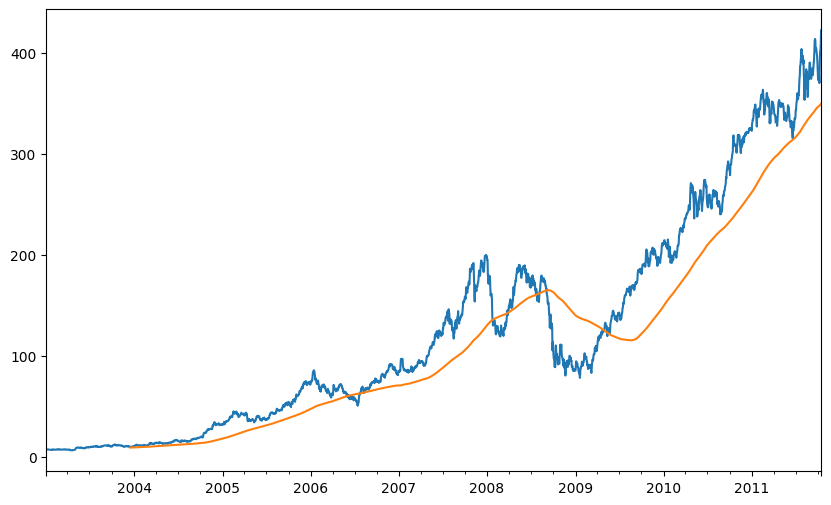

In [255]:
close_px.AAPL.plot()
close_px.AAPL.rolling(250).mean().plot()

In [256]:
plt.figure()

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Axes: >

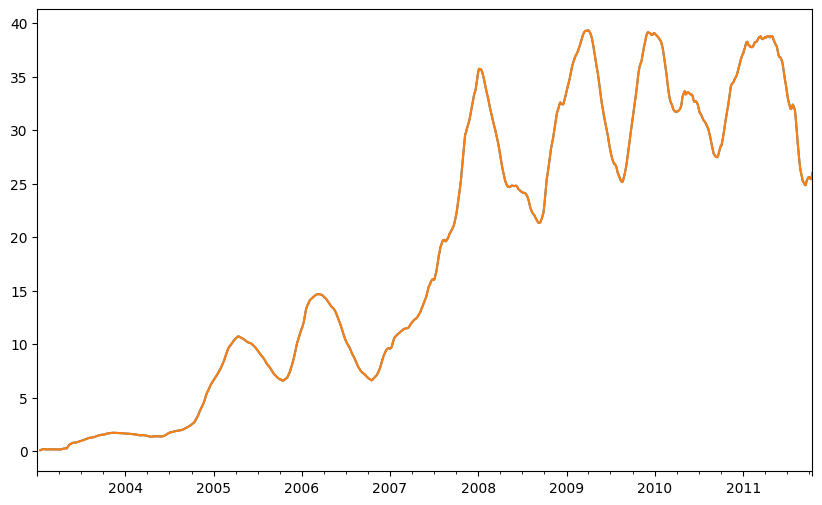

In [257]:
#It creates a time-series line chart of Apple’s 250-day rolling standard deviation.
appl_std250 = close_px.AAPL.rolling(250, min_periods=10).std()
appl_std250[5:12]
appl_std250.plot()
appl_std250 = close_px.AAPL.rolling(250, min_periods=10).std()
appl_std250[5:12]
appl_std250.plot()

In [258]:
expanding_mean = appl_std250.expanding().mean()

In [259]:
plt.figure()

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Axes: >

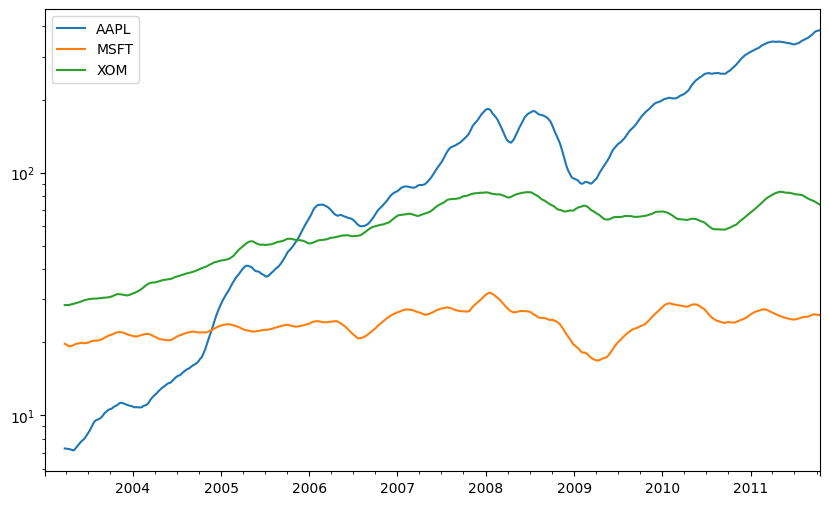

In [260]:
close_px.rolling(60).mean().plot(logy=True)

In [261]:
close_px.rolling('20D').mean()

,AAPL,MSFT,XOM
2003-01-02,7.40,21.11,29.22
2003-01-03,7.43,21.12,29.23
2003-01-06,7.43,21.26,29.47
2003-01-07,7.43,21.43,29.34
2003-01-08,7.40,21.40,29.24
...,...,...,...
2011-10-10,389.35,25.60,72.53
2011-10-11,388.51,25.67,72.83
2011-10-12,388.53,25.81,73.40
2011-10-13,388.83,25.96,73.91


### Exponentially Weighted Functions

In [262]:
plt.figure()

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

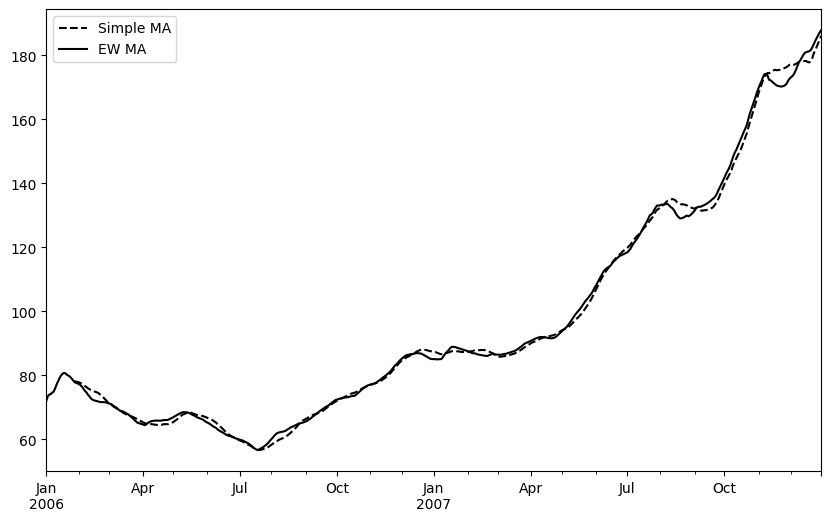

In [263]:
aapl_px = close_px.AAPL['2006':'2007']
ma60 = aapl_px.rolling(30, min_periods=20).mean()
ewma60 = aapl_px.ewm(span=30).mean()
ma60.plot(style='k--', label='Simple MA')
ewma60.plot(style='k-', label='EW MA')
plt.legend()

### Binary Moving Window Functions

In [264]:
plt.figure()

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [265]:
spx_px = close_px_all['SPX']
spx_rets = spx_px.pct_change()
returns = close_px.pct_change()

<Axes: >

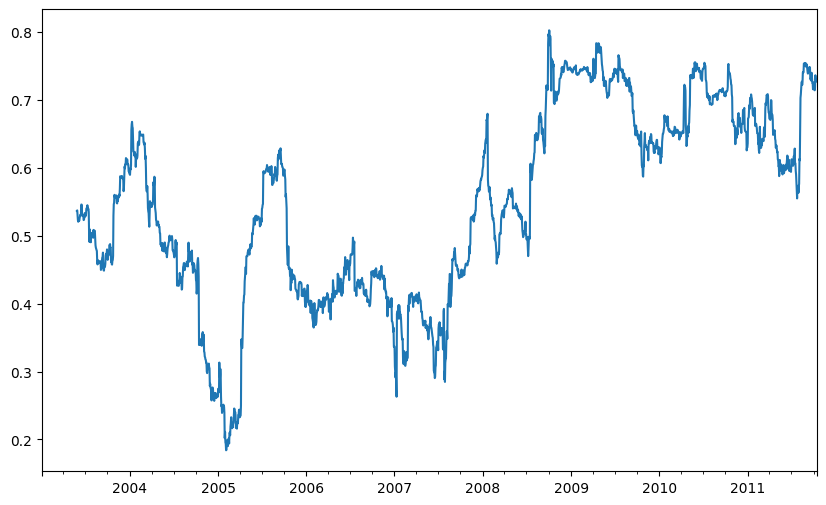

In [266]:
corr = returns.AAPL.rolling(125, min_periods=100).corr(spx_rets)
corr.plot()

In [267]:
plt.figure()

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Axes: >

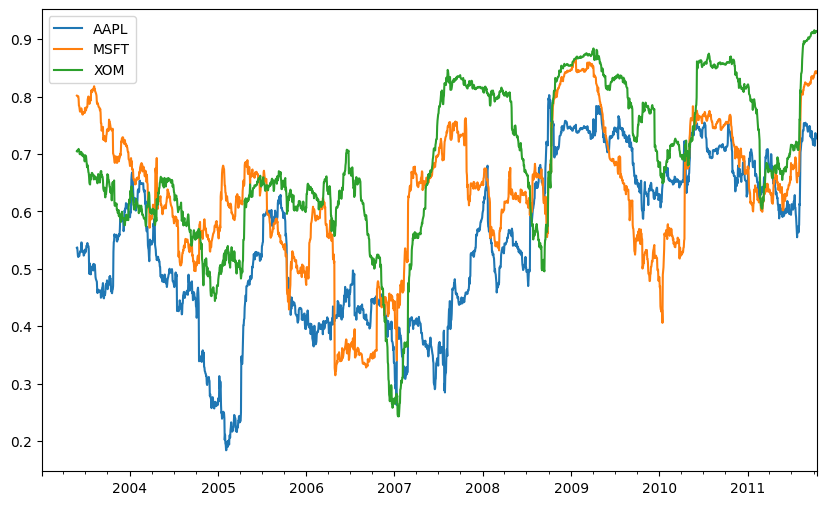

In [268]:
corr = returns.rolling(125, min_periods=100).corr(spx_rets)
corr.plot()

### User-Defined Moving Window Functions

In [269]:
plt.figure()

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Axes: >

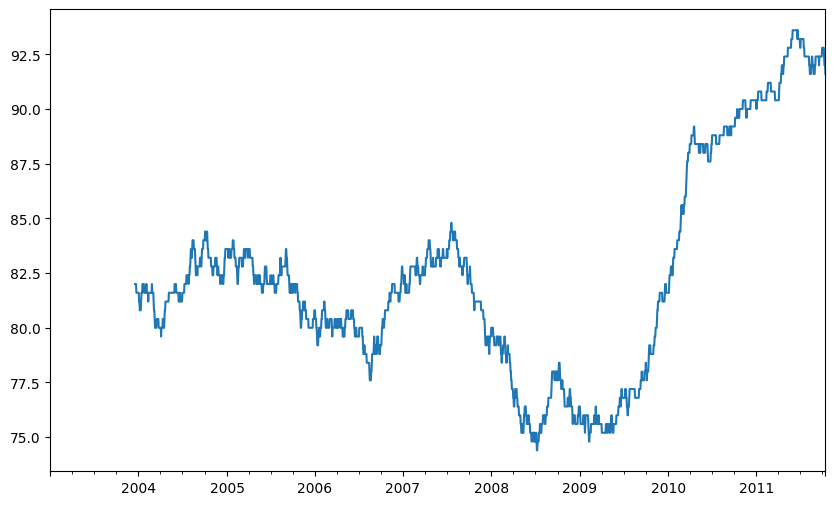

In [270]:
from scipy.stats import percentileofscore
score_at_2percent = lambda x: percentileofscore(x, 0.02)
result = returns.AAPL.rolling(250).apply(score_at_2percent)
result.plot()

In [271]:
pd.options.display.max_rows = PREVIOUS_MAX_ROWS

## Conclusion